# Classical Model Comparison

Compare two IMDB sentiment paths on the same cleaned data and stratified validation split:

1. TF-IDF features with logistic regression.
2. Averaged Word2Vec features with logistic regression.

This notebook intentionally omits neural sentiment models.

In [2]:
# standard library
from pathlib import Path
import sys
from time import perf_counter

# third-party
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay

# local
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

scripts_path = str(PROJECT_ROOT / "scripts")
if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

from imdb_dataset_helpers import clean_reviews, load_datasets
from imdb_model_helpers import (
    average_word_vectors,
    evaluate_classifier,
    split_labeled_reviews,
)

## Configuration

Both paths use these settings and the exact same split. Word2Vec uses one worker to improve reproducibility.

In [3]:
RANDOM_STATE = 42
VALIDATION_SIZE = 0.20
MAX_TFIDF_FEATURES = 100_000
WORD2VEC_DIMENSIONS = 100

## Load, clean, and split
- load fresh data
- apply cleanup
- Kaggle test set is not used during this validation comparison

In [4]:
train, _ = load_datasets()
train_clean = clean_reviews(train)

X_train_text, X_validation_text, y_train, y_validation = split_labeled_reviews(
    train_clean,
    validation_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
)

pd.DataFrame(
    {
        "rows": {"training": len(X_train_text), "validation": len(X_validation_text)},
        "positive_rate": {
            "training": y_train.mean(),
            "validation": y_validation.mean(),
        },
    }
)

Kaggle files already present; using: (project_root)/data/raw


,rows,positive_rate
training,19922,0.500803
validation,4981,0.500703


## Approach 1: TF-IDF + logistic regression

Fit the vocabulary and inverse-document-frequency weights on the training fold only, then transform validation text with that fitted vectorizer.

In [5]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=MAX_TFIDF_FEATURES,
    sublinear_tf=True,
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_validation_tfidf = tfidf.transform(X_validation_text)
X_train_tfidf.shape, X_validation_tfidf.shape

((19922, 100000), (4981, 100000))

In [6]:
tfidf_classifier = LogisticRegression(
    max_iter=1_000,
    random_state=RANDOM_STATE,
)

start = perf_counter()
tfidf_classifier.fit(X_train_tfidf, y_train)
tfidf_fit_seconds = perf_counter() - start

tfidf_result = evaluate_classifier(
    name="TF-IDF + logistic regression",
    classifier=tfidf_classifier,
    features=X_validation_tfidf,
    labels=y_validation,
    fit_seconds=tfidf_fit_seconds,
    feature_count=X_train_tfidf.shape[1],
)
pd.Series(tfidf_result)

model          TF-IDF + logistic regression
roc_auc                            0.963842
accuracy                           0.898815
f1                                 0.899841
features                             100000
fit_seconds                        1.129101
dtype: object

## Approach 2: Word2Vec + logistic regression

Train skip-gram Word2Vec embeddings only on the training fold. Each review becomes the mean of its in-vocabulary word vectors before logistic regression.

In [7]:
X_train_tokens = [simple_preprocess(review) for review in X_train_text]
X_validation_tokens = [simple_preprocess(review) for review in X_validation_text]

len(X_train_tokens), X_train_tokens[0][:20]

(19922,
 ['this',
  'game',
  'has',
  'the',
  'dis',
  'honor',
  'of',
  'being',
  'the',
  'first',
  'game',
  'that',
  'have',
  'stopped',
  'playing',
  'right',
  'in',
  'the',
  'middle',
  'of'])

In [8]:
start = perf_counter()
word2vec = Word2Vec(
    sentences=X_train_tokens,
    vector_size=WORD2VEC_DIMENSIONS,
    window=5,
    min_count=2,
    workers=1,
    sg=1,
    epochs=5,
    seed=RANDOM_STATE,
)

X_train_word2vec = average_word_vectors(X_train_tokens, word2vec.wv)
X_validation_word2vec = average_word_vectors(X_validation_tokens, word2vec.wv)

word2vec_classifier = LogisticRegression(
    max_iter=1_000,
    random_state=RANDOM_STATE,
)
word2vec_classifier.fit(X_train_word2vec, y_train)
word2vec_fit_seconds = perf_counter() - start

word2vec_result = evaluate_classifier(
    name="Word2Vec mean + logistic regression",
    classifier=word2vec_classifier,
    features=X_validation_word2vec,
    labels=y_validation,
    fit_seconds=word2vec_fit_seconds,
    feature_count=X_train_word2vec.shape[1],
)
pd.Series(word2vec_result)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

model          Word2Vec mean + logistic regression
roc_auc                                   0.932796
accuracy                                   0.86328
f1                                        0.864316
features                                       100
fit_seconds                              86.684294
dtype: object

## Side-by-side results

ROC-AUC is the primary comparison. Accuracy and F1 provide complementary threshold-based views; fit time includes embedding training for the Word2Vec path.

In [9]:
results = (
    pd.DataFrame([tfidf_result, word2vec_result])
    .set_index("model")
    .sort_values("roc_auc", ascending=False)
)
results.round({"roc_auc": 4, "accuracy": 4, "f1": 4, "fit_seconds": 2})

,roc_auc,accuracy,f1,features,fit_seconds
model,,,,,
TF-IDF + logistic regression,0.9638,0.8988,0.8998,100000,1.13
Word2Vec mean + logistic regression,0.9328,0.8633,0.8643,100,86.68


## Validation ROC curves

Plot both models against the same validation labels. Curves closer to the upper-left corner indicate stronger ranking performance across classification thresholds.

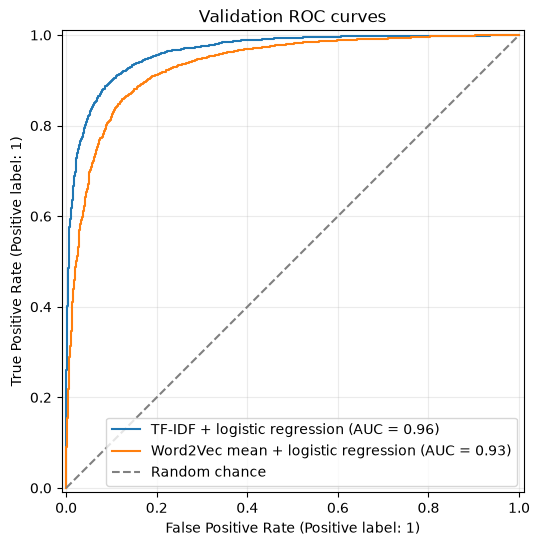

In [ ]:
tfidf_probabilities = tfidf_classifier.predict_proba(X_validation_tfidf)[:, 1]
word2vec_probabilities = word2vec_classifier.predict_proba(X_validation_word2vec)[:, 1]

figure, axis = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_validation,
    tfidf_probabilities,
    name="TF-IDF + logistic regression",
    ax=axis,
)
RocCurveDisplay.from_predictions(
    y_validation,
    word2vec_probabilities,
    name="Word2Vec mean + logistic regression",
    ax=axis,
)
axis.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random chance")
axis.set_title("Validation ROC curves")
axis.grid(alpha=0.25)
axis.legend(loc="lower right")
plt.show()